## 1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

**Anomaly Detection** is the process of finding data points that don’t fit the usual pattern — basically, spotting the “odd ones out.”

### **Types of Anomalies:**

1. **Point Anomalies**

   * A single data point is unusual compared to the rest.
   * **Example:** A daily temperature of 50°C when normally it’s around 25°C.

2. **Contextual Anomalies**

   * A data point is unusual **in a specific context**.
   * **Example:** Spending \$5000 in a day is normal for Black Friday, but unusual on a normal day.

3. **Collective Anomalies**

   * A group of data points together is unusual, even if single points seem normal.
   * **Example:** A sudden spike of 1000 failed login attempts in 10 minutes — one failure is normal, but many together is suspicious.

In short: anomaly detection helps catch weird patterns early, like fraud, errors, or system faults.

## 2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.


| Method                     | Approach                                                                         | Suitable Use Case                                 | Limitation                                                      |
| -------------------------- | -------------------------------------------------------------------------------- | ------------------------------------------------- | --------------------------------------------------------------- |
| Isolation Forest           | Randomly splits data to isolate points; anomalies are easier to separate         | High-dimensional, large datasets; point anomalies | Poor for contextual anomalies; sensitive to parameters          |
| DBSCAN                     | Density-based clustering; points in sparse regions are anomalies                 | Detecting cluster-based or collective anomalies   | Struggles with varying densities; not ideal for high dimensions |
| Local Outlier Factor (LOF) | Compares local density of a point to neighbors; low-density points are anomalies | Detecting local anomalies relative to neighbors   | Computationally heavy; sensitive to neighbor size               |

Isolation Forest is good for large datasets, DBSCAN for sparse clusters, LOF for context-dependent anomalies.


## 3. What are the key components of a Time Series? Explain each with one example.

A **time series** is a sequence of data points recorded over time. Its key components are:

1. **Trend**  The long-term movement or direction in the data.

   * *Example: A companys sales steadily increasing over years.

2. **Seasonality**  Regular, repeating patterns over fixed periods.

   * *Example: Ice cream sales peaking every summer.

3. **Cyclicality**  Fluctuations that occur over irregular, longer periods due to economic or business cycles.

   * *Example: Stock market rises and falls over several years.

4. **Noise (Irregular Component)**  Random, unpredictable variations.

   * *Example: Daily weather changes that dont follow a pattern.

In short: **Trend** shows the direction, **seasonality** repeats regularly, **cyclicality** varies irregularly, and **noise** is randomness.


## 4.  Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

**Stationary in Time Series:**
A time series is **stationary** if its mean, variance, and patterns don’t change over time.

**Testing Stationarity:**

* **Plot the series** to check for trends/seasonality.
* **ADF or KPSS test** (p < 0.05 → stationary).

**Making a Series Stationary:**

* **Differencing:** subtract previous value.
* **Log or power transform:** stabilize variance.
* **Remove trend/seasonality:** via moving average or decomposition.


## 5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

Here’s a concise differentiation of the models:

| Model                                      | Structure                                                                | Application                                                                              |
| ------------------------------------------ | ------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------- |
| **AR (AutoRegressive)**                    | Uses past values of the series to predict future values.                 | Works well when past values strongly influence future values.                            |
| **MA (Moving Average)**                    | Uses past forecast errors (residuals) for prediction.                    | Useful when noise/errors carry information.                                              |
| **ARIMA (AR + I + MA)**                    | Combines AR and MA with **differencing (I)** to handle non-stationarity. | General-purpose forecasting when trend exists but no strong seasonality.                 |
| **SARIMA (Seasonal ARIMA)**                | Extends ARIMA with seasonal AR, I, MA terms.                             | Suitable for data with repeating seasonal patterns (monthly sales, weather).             |
| **SARIMAX (SARIMA + eXogenous variables)** | Adds external regressors (X) to SARIMA.                                  | Used when outside factors affect the series (e.g., sales influenced by marketing spend). |

In short:

* **AR & MA** are basic building blocks.
* **ARIMA** handles non-stationary trends.
* **SARIMA** handles both trend and seasonality.
* **SARIMAX** adds external factors.

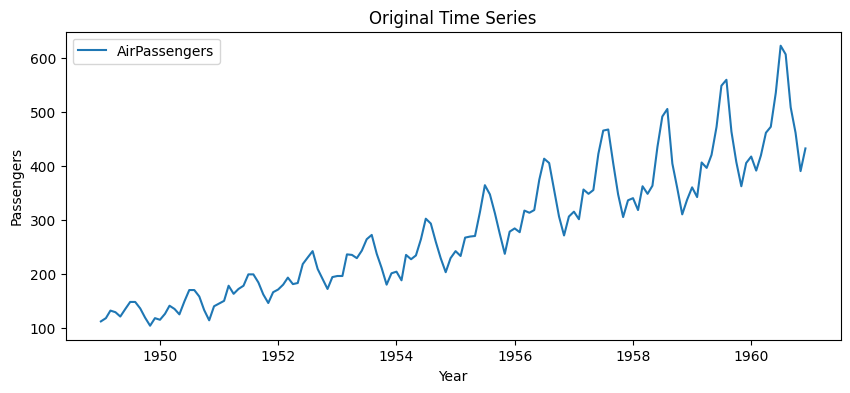

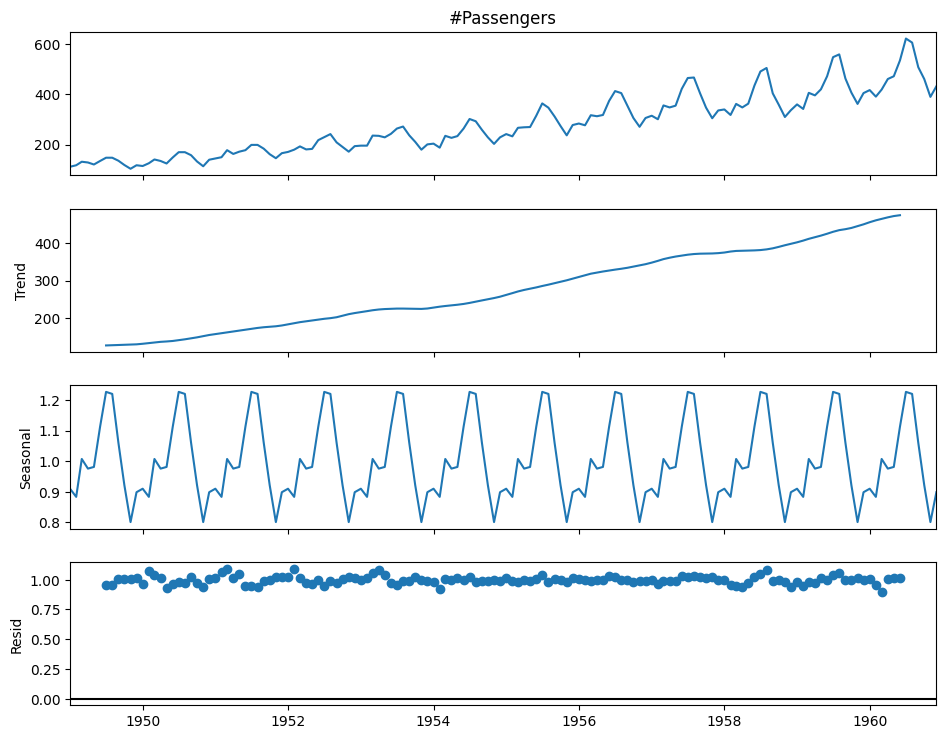

In [25]:
# 6. Load a time series dataset (e.g., AirPassengers), plot the original series,
# and decompose it into trend, seasonality, and residual components

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = pd.read_csv('AirPassengers.csv')
data
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
ts = data['#Passengers']

plt.figure(figsize=(10, 4))
plt.plot(ts, label='AirPassengers')
plt.title("Original Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Decompose into trend, seasonality, and residual
decomposition = seasonal_decompose(ts, model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()


In [26]:
# 7.  Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies.
# Visualize the anomalies on a 2D scatter plot.

data = pd.read_csv('NYC_taxi_fare_data.csv')
data

C:\Users\prami\AppData\Local\Temp\ipykernel_13616\3545562862.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('NYC_taxi_fare_data.csv')


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.00,3.00,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.00,3.00,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.00,3.00,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.50,0.50,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.50,0.50,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.00,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.00,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.00,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.00,0.00,0.3,30.22,0.0


d:\PWSkills\PW_Skills_Assignments\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


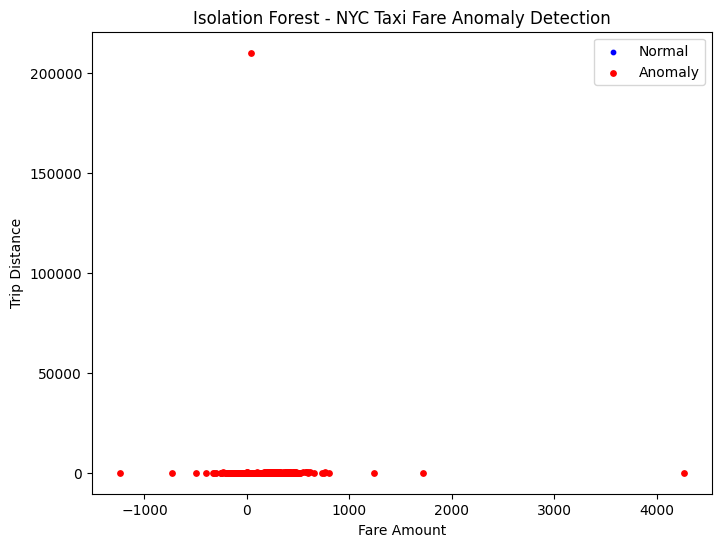

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Select useful numeric columns and drop missing values
df = data[['fare_amount', 'trip_distance']].dropna()

# Apply Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = iso.fit_predict(df[['fare_amount', 'trip_distance']])

# Separate anomalies and normal points
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(normal['fare_amount'], normal['trip_distance'], c='blue', s=10, label='Normal')
plt.scatter(anomalies['fare_amount'], anomalies['trip_distance'], c='red', s=15, label='Anomaly')
plt.xlabel("Fare Amount")
plt.ylabel("Trip Distance")
plt.title("Isolation Forest - NYC Taxi Fare Anomaly Detection")
plt.legend()
plt.show()


d:\PWSkills\PW_Skills_Assignments\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\PWSkills\PW_Skills_Assignments\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


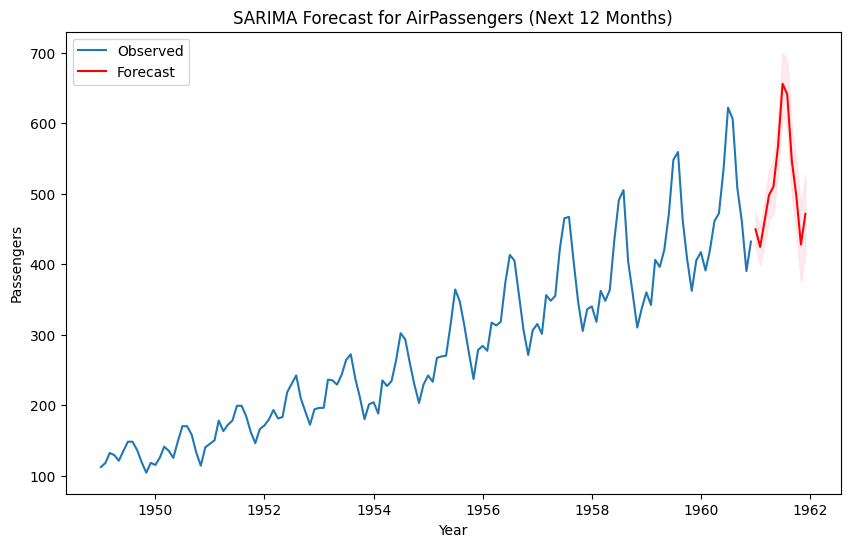

In [31]:
# 8. Train a SARIMA model on the monthly airline passengers dataset.
# Forecast the next 12 months and visualize the results.


from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
ts = data['#Passengers']

# Fit SARIMA model
# (p,d,q) = (1,1,1), seasonal_order=(1,1,1,12) is a common starting point
model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(),
                               periods=12, freq='MS')
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)
conf_int = forecast.conf_int()

# Plot results
plt.figure(figsize=(10,6))
plt.plot(ts, label='Observed')
plt.plot(forecast_series, label='Forecast', color='red')
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast for AirPassengers (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()


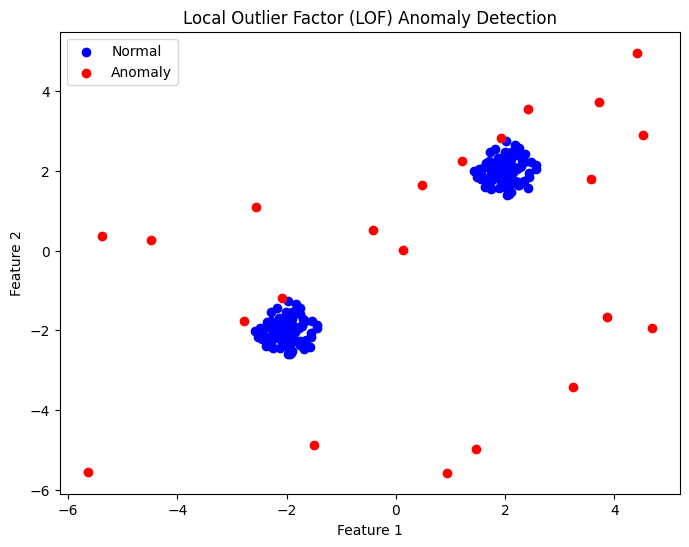

In [32]:
# 9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib

import numpy as np
from sklearn.neighbors import LocalOutlierFactor

# Example dataset (you can replace with your own numeric dataset)
np.random.seed(42)
# Generate normal data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Add some anomalies
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

# Combine into one dataset
X = np.r_[X_inliers, X_outliers]

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# -1 = anomaly, 1 = normal
normal = X[y_pred == 1]
anomalies = X[y_pred == -1]

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomaly')
plt.title("Local Outlier Factor (LOF) Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## 10. : You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage. Explain your real-time data science workflow: How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)? Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)? How would you validate and monitor the performance over time? How would this solution help business decisions or operations?


### **1. Anomaly Detection in Streaming Data**

* **Approach:** Use models that can detect unusual consumption patterns in near real-time.
* **Choice:**

  * **Isolation Forest** → handles high-dimensional numeric data, scalable, good for point anomalies (sudden spikes/drops).
  * **LOF** → useful if anomalies depend on local context (e.g., a region behaves differently than its neighbors).
  * **DBSCAN** → useful if anomalies form clusters (e.g., multiple sensors showing abnormal patterns together).
* **Implementation:** Process the streaming data in windows (e.g., last 1 hour), run anomaly detection, flag sudden spikes/drops.

---

### **2. Short-Term Forecasting Model**

* **Goal:** Forecast energy demand for the next few hours.
* **Choice:**

  * **SARIMAX** → best option since energy demand depends on **time (trend + seasonality)** and **external variables like weather**.
  * If scalability and real-time adaptation are crucial, also consider **Prophet** or **LSTM-based models**.

---

### **3. Validation and Monitoring**

* **Validation:**

  * Use rolling-origin evaluation (walk-forward validation).
  * Metrics: **MAE, RMSE, MAPE** for forecast accuracy.
  * Precision/recall for anomaly detection.
* **Monitoring:**

  * Track model error drift in real-time.
  * Set alerts if forecast error exceeds a threshold.
  * Retrain periodically with the latest data to adapt to changes.

---

### **4. Business Value**

* **Operational Efficiency:** Accurate forecasts help schedule power generation and avoid shortages/overproduction.
* **Cost Savings:** Detecting anomalies early prevents losses due to equipment failure or sudden demand surges.
* **Reliability:** Ensures stable grid operation, avoiding blackouts.
* **Decision Support:** Provides grid operators and managers with actionable alerts and demand forecasts.

---